In [59]:
import pandas as pd
from matplotlib import pyplot as plt

In [60]:
df=pd.read_csv("Pizza pricing.csv")

In [61]:
df.head()

,Date,Diameter(X),Price(Y)
0,11.02.2026,8,10
1,20.02.2026,10,13
2,25.03.2026,12,16
3,02.04.2026,6,8
4,10.04.2026,7,9


In [62]:
print(df)

          Date  Diameter(X)  Price(Y)
0   11.02.2026            8        10
1   20.02.2026           10        13
2   25.03.2026           12        16
3   02.04.2026            6         8
4   10.04.2026            7         9
5   18.04.2026            9        12
6   25.04.2026           11        15
7   02.05.2026           13        18
8   10.05.2026           14        20
9   18.05.2026           15        22
10  25.05.2026           16        24
11  02.06.2026            5         7
12  10.06.2026           17        26
13  18.06.2026           18        28
14  25.06.2026           19        30


Text(0.5, 1.0, 'Predicting Pizza Prices')

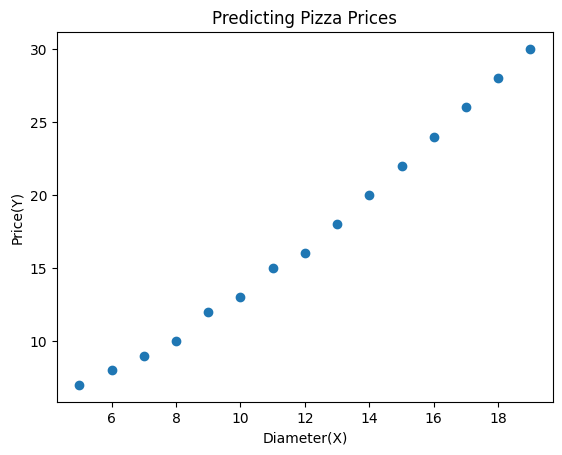

In [63]:
plt.scatter(df["Diameter(X)"],df["Price(Y)"])
plt.xlabel('Diameter(X)')
plt.ylabel('Price(Y)')
plt.title('Predicting Pizza Prices')

In [64]:
x=df[['Diameter(X)']]
x.head()

,Diameter(X)
0,8
1,10
2,12
3,6
4,7


In [65]:
y=df[['Price(Y)']]
y.head()

,Price(Y)
0,10
1,13
2,16
3,8
4,9


Linear Regrassion

In [ ]:
pip install  sklearn

In [ ]:
pip install scikit-learn

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
reg=LinearRegression()

In [70]:
x.mean()


Diameter(X)    12.0
dtype: float64

In [71]:
y.mean()

Price(Y)    17.2
dtype: float64

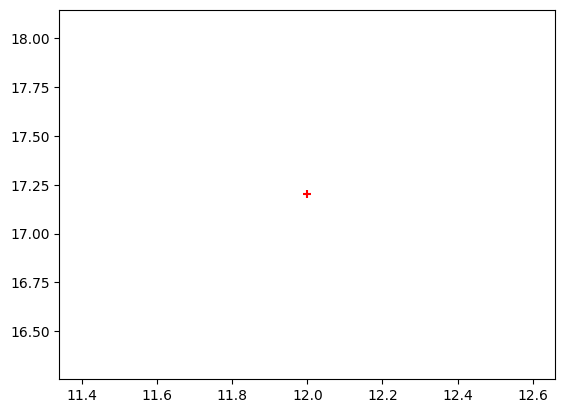

In [72]:
plt.scatter(x.mean(),y.mean(),color='red',marker='+')


In [73]:
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
#value of m
m=reg.coef_
m



array([[1.675]])

In [75]:
b=reg.intercept_
b

array([-2.9])

Y=mX+b

In [76]:
m*18+b

array([[27.25]])

In [77]:
reg.predict([[18]])

c:\Users\IFFATH\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[27.25]])

In [78]:
df['predicted_price']=reg.predict(x)
df.head()

,Date,Diameter(X),Price(Y),predicted_price
0,11.02.2026,8,10,10.500
1,20.02.2026,10,13,13.850
2,25.03.2026,12,16,17.200
3,02.04.2026,6,8,7.150
4,10.04.2026,7,9,8.825


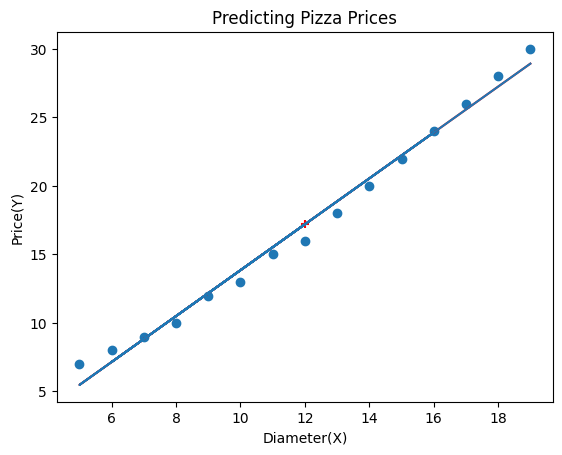

In [84]:
plt.plot(x,df['predicted_price'],color='red')
plt.plot(x,reg.predict(x))
plt.scatter(df["Diameter(X)"],df["Price(Y)"])
plt.xlabel('Diameter(X)')
plt.ylabel('Price(Y)')
plt.title('Predicting Pizza Prices')
plt.scatter(x.mean(),y.mean(),color='red',marker='+')

Lose and Cost Function:

In [85]:
df['lose']=df['Diameter(X)']-df['Price(Y)']
df.head()

,Date,Diameter(X),Price(Y),predicted_price,lose
0,11.02.2026,8,10,10.500,-2
1,20.02.2026,10,13,13.850,-3
2,25.03.2026,12,16,17.200,-4
3,02.04.2026,6,8,7.150,-2
4,10.04.2026,7,9,8.825,-2


MSE calculate

In [86]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [87]:
mse=mean_squared_error(df['Price(Y)'],df['predicted_price'])
mse

0.5883333333333334

In [88]:
ame=mean_absolute_error(df['Price(Y)'],df['predicted_price'])
ame

0.6533333333333334

R sqr Value/Accuracy of Regrassion

In [89]:
reg.score(x,y)

0.9888909869083585

In [90]:
from sklearn.metrics import r2_score
r2_score(y,reg.predict(x))


0.9888909869083585